# Lab 3B: Post-processing and Analysis of Molecular Dynamics Trajectories
### University of California, Berkeley - Spring 2026 - ME 120/292A

## Overview

### Purpose

The purpose of this lab is to introduce basic molecular dynamics (MD) post-processing techniques using a precomputed trajectory. You will clean up a trajectory for analysis and visualization, and compute a few standard metrics that summarize and better quantify protein dynamics.

### Environment

In this lab, you will use:

* **MDAnalysis** (trajectory I/O, atom selections, alignment, analysis)
* **NumPy / Pandas** (arrays, tables, saving results)
* **Matplotlib** (plots and figures)

Files you will work with:

* **Topology / structure:** `.pdb`, `.cif`
* **Trajectory:** `.dcd`
* **Notebook:** `.ipynb`

> Platforms: UC Berkeley DataHub or local (macOS, Linux, Windows with WSL)

### Objectives

By the end of the lab, you should be able to:

* Load a structure + trajectory and verify the system looks reasonable.
* Correct common periodic boundary condition (PBC) artifacts for analysis/visualization.
* Align a protein trajectory to a reference structure.
* Compute, plot, and interpret **RMSD**, **RMSF**, and **radius of gyration (RG)**.

### Submission

Submit a short, typeset PDF report (**1-2 pages**) that includes:

* Three captioned figures: **RMSD vs time**, **RMSF vs residue**, **RG vs time**
* Brief answers to the report questions (Q1–Q4), referencing your figures
* Filename: `lab3_{firstname}_{lastname}.pdf` submitted to bCourses


## Setup

### Files
Ensure these provided files are in a folder named `data/` next to this notebook:
- `data/hpr_1poh_traj.dcd`
- `data/hpr_1poh_structure.pdb`

### Dependencies

Option 1: Create the environment from YAML (Recommended):
```bash
conda env create -f lab3-environment.yml
```

Option 2: Create environment manually:
```bash
conda create -n mdanalysis python=3.11
conda activate mdanalysis
conda install ipykernel mdanalysis matplotlib
```

Activate:
```bash
conda activate mdanalysis
```

Make conda environment into IPython Kernel
```bash
python -m ipykernel install --user --name mdanalysis --display-name mdanalysis
```

In Jupyter, select the kernel:

* Top right kernel picker, or **Kernel** > **Change Kernel** > **mdanalysis**

> If the Kernel does not show up, you may need to refresh/reload your page
 
Check: run the next cell. You should see package versions and no errors.

In [1]:
import os

import numpy as np
import matplotlib.pyplot as plt

import MDAnalysis as mda
from MDAnalysis.analysis import align, rms
from MDAnalysis import transformations as trans
from MDAnalysis.analysis.rms import RMSF

c:\Users\kentc\miniconda3\envs\mdanalysis\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\kentc\miniconda3\envs\mdanalysis\Lib\site-packages\Bio\Application\__init__.py:39: BiopythonDeprecationWarning: The Bio.Application modules and modules relying on it have been deprecated.

Due to the on going maintenance burden of keeping command line application
wrappers up to date, we have decided to deprecate and eventually remove these
modules.

We instead now recommend building your command line and invoking it directly
with the subprocess module.
  warnings.warn(


## Background

In this lab, you will **analyze a precomputed MD simulation** (you are not running MD from scratch). The goal is to use standard structural metrics to answer:

**Did this bacterial protein remain structurally stable in water, and which regions were the most flexible?**

### HPr (E. coli)
The protein in this trajectory is **HPr** (histidine-containing phosphocarrier protein), a small cytosolic bacterial protein in the **phosphotransferase system (PTS)**, where it helps transfer a phosphate signal between PTS components during sugar uptake.

For this lab, HPr is a convenient example because it is a **small, soluble bacterial protein**, making MD analysis fast and interpretable.

### Structure preview
Try the interactive viewer below. If it does not load, open the links:

- RCSB PDB entry: https://www.rcsb.org/structure/1poh  
- 3D view (Mol*): https://www.rcsb.org/3d-view/1POH  

<iframe
  src="https://molstar.org/viewer/?pdb=1POH"
  width="100%"
  height="420"
  style="border: 1px solid #ddd; border-radius: 6px;"
  loading="lazy"
></iframe>

### What the trajectory represents
A trajectory (`.dcd`) is a sequence of saved coordinate frames. You can think of it as a flipbook: each frame is one snapshot of the atoms, and playing frames in order shows motion over time.

In this notebook, you will turn the trajectory into quantitative summaries:
- **RMSD**: overall structural deviation from a reference structure
- **RMSF**: per-residue flexibility (here, using C-alpha atoms)
- **RG**: overall compactness (radius of gyration)

### Files (what you are given, and how we use them)
| File | What it is | How we use it |
|---|---|---|
| `data/hpr_1poh_structure.pdb` | Structure file (atom names, residues, coordinates for one frame) | Reference structure + “structure/topology” for MDAnalysis/VMD |
| `data/hpr_1poh_traj.dcd` | Raw trajectory (many frames of coordinates) | Input trajectory to be cleaned |
| `outputs/hpr_1poh_traj_fixed.dcd` | Cleaned trajectory (created in this notebook) | Used for all plots and VMD visualization |

### Why we “fix” the trajectory
This simulation used **periodic boundary conditions (PBC)**: the water box is treated as if it repeats in all directions (like tiles). When atoms leave one side of the box, they re-enter from the opposite side.  
A common side effect is that saved coordinates can make the protein look **split across the box edge** or **jumping** between sides. This is an imaging artifact, not real physics. We clean the trajectory so the protein stays **whole and centered**.

### Simulation details (OpenMM)
This simulation was run using **OpenMM** (via OpenMM-Setup). The table below lists the main parameters used.

| Item | Value |
|---|---|
| Engine | OpenMM (OpenMM-Setup generated script) |
| Starting structure | prepared from PDB 1POH |
| Protein force field | AMBER14 (`amber14-all.xml`) |
| Water model | TIP3P-FB (`amber14/tip3pfb.xml`) |
| Electrostatics | PME |
| Nonbonded cutoff | 1.0 nm |
| Ensemble | NPT (constant temperature and pressure) |
| Temperature | 300 K |
| Pressure | 1 atm (Monte Carlo barostat) |
| Integrator | LangevinMiddle |
| Integrator timestep | 2 fs |
| Production length | 500,000 steps |
| Trajectory save stride | every 10,000 steps |


   
> **Note:** You will use the timestep and stride information above to determine the **time between saved frames** when you build the time axis for your plots.

## 1. Post-Processing

In [ ]:
structure_path = "data/hpr_1poh_structure.pdb"
trajectory_path = "data/hpr_1poh_traj.dcd"

u = mda.Universe(structure_path, trajectory_path)

protein = u.select_atoms("protein")
backbone = u.select_atoms("protein and backbone")
calpha = u.select_atoms("protein and name CA")

c:\Users\kentc\miniconda3\envs\mdanalysis\Lib\site-packages\MDAnalysis\coordinates\DCD.py:171: DeprecationWarning: DCDReader currently makes independent timesteps by copying self.ts while other readers update self.ts inplace. This behavior will be changed in 3.0 to be the same as other readers. Read more at https://github.com/MDAnalysis/mdanalysis/issues/3889 to learn if this change in behavior might affect you.
  warnings.warn("DCDReader currently makes independent timesteps"


### Fix the Trajectory

#### Periodic Boundary Conditions (PBC)
To simulate a small piece of a large water environment, MD often uses **periodic boundary conditions**. You can picture the simulation box as being tiled in all directions. If an atom leaves one side of the box, it re-enters from the opposite side. This avoids unrealistic "walls," but it can make molecules look strange in the saved coordinates.

A common artifact is that the protein can appear **split across the box boundary** or **jumping** from one side to the other. This is a coordinate/imaging artifact, not a real physical event.

#### What this fixing step does
We create a cleaned trajectory by applying three standard operations to every frame:
1. **Unwrap** the protein (make it whole, not split across boundaries)
2. **Center** the protein in the box (keep it near the middle)
3. **Wrap** water/ions back into the box (so the box still looks like a water box)

After this step, the protein should stay **in one piece** and **near the center**, which makes plots and VMD movies easier to interpret.

This creates a new trajectory file you can reuse in both:
- this notebook (metrics)
- VMD (visualization)

Output:
- `outputs/hpr_1poh_traj_fixed.dcd`

In [3]:
out_dir = "outputs"
fig_dir = f"{out_dir}/figures"
os.makedirs(fig_dir, exist_ok=True)
fixed_trajectory_path = f"{out_dir}/hpr_1poh_traj_fixed.dcd"
os.makedirs(out_dir, exist_ok=True)

if not os.path.exists(fixed_trajectory_path):
    # unwrap() works best if the protein has bonds
    protein.guess_bonds()

    workflow = [
        trans.unwrap(protein),
        trans.center_in_box(protein, center="geometry"),
        trans.wrap(u.atoms, compound="residues"),
    ]
    u.trajectory.add_transformations(*workflow)

    with mda.Writer(fixed_trajectory_path, n_atoms=u.atoms.n_atoms) as W:
        for ts in u.trajectory:
            W.write(u.atoms)

# Reload the Universe using the fixed trajectory
u = mda.Universe(structure_path, fixed_trajectory_path)
protein  = u.select_atoms("protein")
backbone = u.select_atoms("protein and backbone")
calpha   = u.select_atoms("protein and name CA")

### Print basic trajectory info

In [5]:
n_frames = len(u.trajectory)
n_atoms = u.atoms.n_atoms
n_residues = protein.residues.n_residues

frame_dt_ps = 20  # TODO: time between saved frames (ps/frame)

t_ns = (np.arange(n_frames) * frame_dt_ps) / 1000.0
total_ns = t_ns[-1] if n_frames > 0 else 0.0

print(f"Summary of {fixed_trajectory_path}\n{'-'*64}")
print(f"Number of Simulation Frames: {n_frames}")
print(f"Number of Atoms in System: {n_atoms}")
print(f"Number of Residues (Amino Acids) in protein selection: {n_residues}")
print(f"Time between frames (ps/frame): {frame_dt_ps:.4g}")
print(f"Total simulated time (ns): {total_ns:.1f}")

Summary of outputs/hpr_1poh_traj_fixed.dcd
----------------------------------------------------------------
Number of Simulation Frames: 50
Number of Atoms in System: 15005
Number of Residues (Amino Acids) in protein selection: 85
Time between frames (ps/frame): 20
Total simulated time (ns): 1.0


## 2. RMSD

### General RMSD definition
The **root-mean-square deviation (RMSD)** measures the typical (average) distance between two sets of points.

Given two sets of $N$ points in 3D, $\{\mathbf{x}_i\}_{i=1}^N$ and $\{\mathbf{y}_i\}_{i=1}^N$, the RMSD is:

$$
\mathrm{RMSD}(\mathbf{x},\mathbf{y}) = \sqrt{\frac{1}{N}\sum_{i=1}^{N}\left\|\mathbf{x}_i-\mathbf{y}_i\right\|^2}
$$

Here, $\|\cdot\|$ is the usual Euclidean norm.

### RMSD for protein structures (what we compute in MD)
In an MD trajectory, each frame is a protein conformation. To measure how the protein changes over time, we compare the coordinates in each frame to a **reference structure**.

Let:
- $\mathbf{x}_i(t)$ = position of atom $i$ at time $t$ (from the trajectory)
- $\mathbf{x}_i^{\mathrm{ref}}$ = position of atom $i$ in the reference structure

Then:

$$
\mathrm{RMSD}(t) = \sqrt{\frac{1}{N}\sum_{i=1}^{N}\left\|\mathbf{x}_i(t)-\mathbf{x}_i^{\mathrm{ref}}\right\|^2}
$$

### Why we align first
If we compared coordinates directly, RMSD would include whole-protein **drift** and **rotation** in the box. To focus on **shape change**, we first align each frame to the reference by finding the rotation $\mathbf{R}(t)$ and translation $\mathbf{t}(t)$ that best superimpose the selected atoms:

$$
\mathbf{x}_i(t)\;\rightarrow\;\mathbf{R}(t)\,\mathbf{x}_i(t) + \mathbf{t}(t)
$$

After alignment, RMSD reflects conformational changes rather than rigid-body motion.

### What we do in this lab
- **Reference:** the first structure in `structure_path`
- **Atom selection:** `protein and backbone`
- **Plot:** backbone RMSD (Angstrom) vs time (ns)

Backbone RMSD is a common choice because backbone atoms capture overall folding and are less noisy than all atoms.

### How to read the RMSD plot
- **RMSD rises then plateaus:** the structure relaxes from the starting conformation and becomes stable.
- **RMSD keeps drifting:** indicates gradual conformational change or incomplete equilibration.
- **Large fluctuations:** suggests the protein samples multiple conformations or has very flexible regions.


In [6]:
ref = mda.Universe(structure_path)

align.AlignTraj(u, ref, select="protein and backbone", in_memory=True).run()
print("Alignment complete.")

Alignment complete.


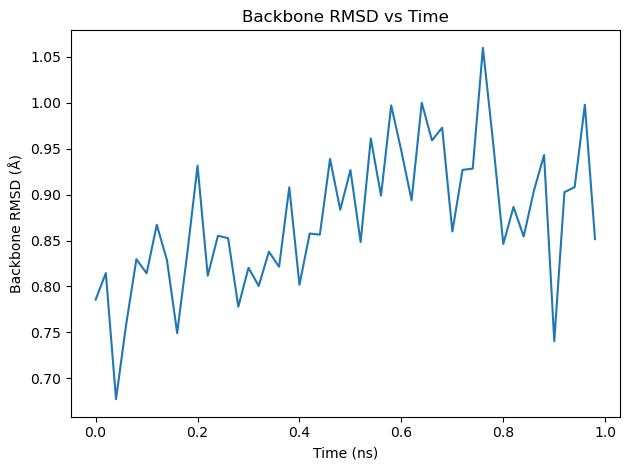

In [7]:
R = rms.RMSD(u, ref, select="protein and backbone").run()
rmsd_A = R.results.rmsd[:, 2]

plt.figure()
plt.plot(t_ns, rmsd_A)
plt.xlabel("Time (ns)")
plt.ylabel("Backbone RMSD (\u212B)")
plt.title("Backbone RMSD vs Time")
plt.tight_layout()

# Save plot to disk
plt.savefig(fname="outputs/figures/rmsd.png")

plt.show()

## 3. RMSF

### General RMSF definition
The **root-mean-square fluctuation (RMSF)** measures how much a point fluctuates around its **average position** over time.

For atom $i$ with positions $\mathbf{x}_i(t)$ across the trajectory, define its time-average position:

$$
\langle \mathbf{x}_i \rangle = \frac{1}{T}\int_0^T \mathbf{x}_i(t)\,dt
$$

In a trajectory with $M$ saved frames, we use the discrete average:

$$
\langle \mathbf{x}_i \rangle = \frac{1}{M}\sum_{k=1}^{M}\mathbf{x}_i(t_k)
$$

Then the RMSF of atom $i$ is:

$$
\mathrm{RMSF}_i = \sqrt{\frac{1}{M}\sum_{k=1}^{M}\left\|\mathbf{x}_i(t_k)-\langle \mathbf{x}_i\rangle\right\|^2}
$$

### RMSF for protein structures (what we compute in MD)
RMSF is usually used to identify **flexible** and **rigid** regions of a protein.

In this lab we compute RMSF for **C-alpha** atoms:
- Each residue has one $\text{C}\alpha$, so this gives a simple **per-residue flexibility** profile.
- RMSF is reported in **Angstroms**.

### Why alignment matters
If the protein is translating/rotating as a whole, RMSF would be artificially large everywhere.  
So we align the trajectory first (the same alignment used for RMSD), and then compute RMSF on the aligned coordinates.

### What we do in this lab
- **Atom selection:** `protein and name CA`
- **Output plot:** $\text{C}\alpha$ RMSF (Angstrom) vs residue ID

### How to read the RMSF plot
- **High RMSF peaks:** flexible regions (often loops or termini).
- **Low RMSF regions:** rigid regions (often the protein core).
- A few large peaks are normal; what matters is the overall pattern and where flexibility is concentrated.


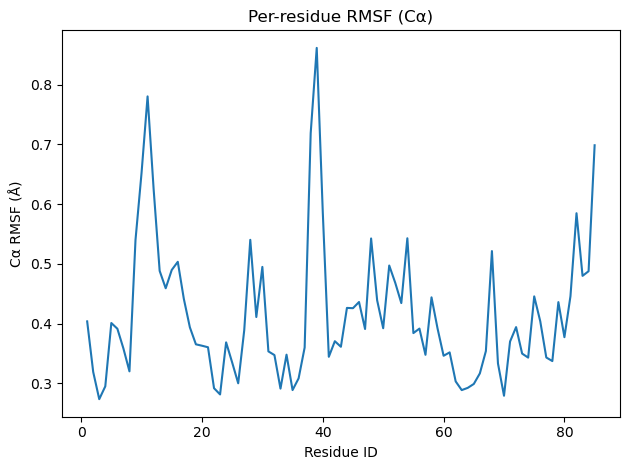

In [8]:
rmsf_A = RMSF(calpha).run().results.rmsf
resids = calpha.resids

plt.figure()
plt.plot(resids, rmsf_A)
plt.xlabel("Residue ID")
plt.ylabel("Cα RMSF (\u212B)")
plt.title("Per-residue RMSF (Cα)")
plt.tight_layout()

plt.savefig(fname="outputs/figures/rmsf.png")

plt.show()

## 4. Radius of Gyration

### General definition
The **radius of gyration** $RG$ is a measure of how spread out a set of points is around their center.  
In MD, it is often used as a simple measure of **compactness**.

First define the **center of mass**:

$$
\mathbf{r}_{\mathrm{CM}}=\frac{\sum_{i=1}^{N} m_i\,\mathbf{r}_i}{\sum_{i=1}^{N} m_i}
$$

where:
- $\mathbf{r}_i$ is the position of atom $i$
- $m_i$ is the mass of atom $i$

Then the radius of gyration is:

$$
RG=\sqrt{\frac{\sum_{i=1}^{N} m_i\,\left\|\mathbf{r}_i-\mathbf{r}_{\mathrm{CM}}\right\|^2}{\sum_{i=1}^{N} m_i}}
$$

### Radius of gyration for a protein (what we compute in MD)
For a protein, $RG$ summarizes the overall size of the protein around its center of mass:
- smaller $RG$ means the protein is **more compact**
- larger $RG$ means the protein is **more extended**

In this lab we compute $RG(t)$ using all atoms in the selection `protein`, for every frame of the trajectory.

### Why we still align first
Unlike RMSD, $RG$ does not depend on absolute position, so alignment is not strictly required.  
However, we keep the workflow consistent (align once, then compute multiple metrics), and alignment can make other metrics (RMSD/RMSF) interpretable.

### What we do in this lab
- **Atom selection:** `protein`
- **Output plot:** $RG$ (Angstrom) vs time (ns)

### How to read the $RG$ plot
- **Roughly constant $RG$:** overall size/compactness stays stable.
- **Decreasing $RG$:** the protein becomes more compact.
- **Increasing $RG$:** the protein becomes more extended.
- **Sudden jumps:** can indicate a large conformational change (or an artifact if the trajectory is not cleaned).


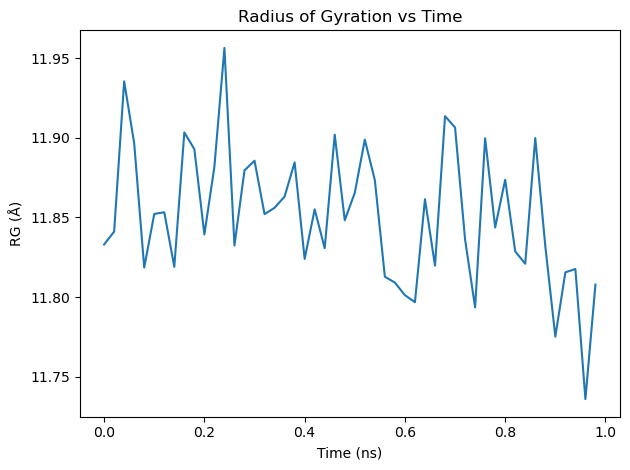

In [9]:
RG_A = np.zeros(n_frames, dtype=float)
for i, ts in enumerate(u.trajectory):
    RG_A[i] = protein.radius_of_gyration()

plt.figure()
plt.plot(t_ns, RG_A)
plt.xlabel("Time (ns)")
plt.ylabel("RG (\u212B)")
plt.title("Radius of Gyration vs Time")
plt.tight_layout()

plt.savefig(fname="outputs/figures/rg.png")

plt.show()


## Deliverable Assignment (9 pts)

Submit a short, typeset PDF report (1-2 pages). Include your three plots (RMSD, RMSF, RG) and answer Q1-Q4. Ensure your plots are captioned as Figures and referenced in your response. Submit as `lab3_{firstname}_{lastname}.pdf` to bCourses.

### Q1 (2 pts): RMSD
Look at your RMSD plot. Does RMSD quickly reach a roughly steady value, or does it keep drifting over time? **50-200 words**.

### Q2 (2 pts): RMSF
Look at your RMSF plot. Which residues have the largest RMSF values? List their residue IDs. Explain what high RMSF indicates physically (what kind of protein regions would you expect to have high RMSF?). **50-200 words**

### Q3 (2 pts): RG
Look at your RG plot. Does the protein become more compact, less compact, or stay about the same during this trajectory? Support your answer using the trend and range you observe. **50-200 words**

### Q4 (3 pts): Biological context & Interpretation
Briefly research **E. coli HPr (PDB: 1POH)** and answer the following: **100-300 words**
- What is HPr and what role does it play in bacteria?
- Based on the simulation setup and your plots, what is one reasonable conclusion you can make about HPr behavior in this simulation? (How does structure relate to function?)
- Name one limitation of this simulation/analysis.

> A good place to start your search is the PDB entry for the protein

**Submission Checklist**
- Your PDF includes the three captioned figures: RMSD vs time, RMSF vs residue, RG vs time.
- Your answers reference the figures (use approximate values when relevant).


## Troubleshooting

### Quick checks
1. Restart the notebook kernel and run again.
2. Confirm your files exist: check the `data/` folder.
3. Re-run the last cell and read the first error message carefully.

### Common issues
- FileNotFoundError: confirm your `data/` folder has `hpr_1poh_structure.pdb` and `hpr_1poh_traj.dcd`.
- Trajectory looks jumpy in VMD: use `outputs/hpr_1poh_traj_fixed.dcd` instead of the raw DCD.

## Collaboration and Academic Integrity

You may discuss high-level ideas and debugging strategies with classmates.
Do not share completed notebooks or written answers.
All submitted work must be your own.

Cite any external resources used (links are fine).

## References

- MDAnalysis documentation (selections, alignment, transformations)
- Course materials (MD lecture + Lab 3 videos)
